In [1]:
from lib.artificial_data import ArtificialTrackDataset, generate_dataset_with_similarities
from lib.user_similarities import calculate_users_track_common_percentage
from lib.plotting import plot_user_similarities_matrix
from lib.matrix_dataset import MatrixDataset
from lib.spoti import NUMERICAL_FEATURES, PRETTY_PRINT_FEATURES
import numpy as np
from IPython.display import display
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import os

In [2]:
SIMPLIFIED_FEATURES = [
    "danceability",
    "duration_ms",
    "instrumentalness",
    "affinity"
]

In [3]:
df_1 = ArtificialTrackDataset(
    default_value=2,
    numerical_features=SIMPLIFIED_FEATURES,
    n_samples=5,
    constant_features={"username": "owen"},
).randomize()

df_2 = ArtificialTrackDataset(
    default_value=3,
    numerical_features=SIMPLIFIED_FEATURES,
    n_samples=5,
    constant_features={"username": "paul"},
).randomize().insert_some_tracks(df_1, 0.5, 0.5)[0].randomize(["affinity"]).shuffle()

df = df_1.merge(df_2)

display(df.data)

,id,username,danceability,duration_ms,instrumentalness,affinity
0,Rich different,owen,0.963201,0.886855,1.052356,1.003681
1,Mission,owen,1.009929,1.131706,1.073693,0.842403
2,If election,owen,0.975216,0.914808,0.926974,0.960186
3,Between,owen,0.995350,1.090412,0.856017,0.688253
4,Citizen,owen,1.048877,1.083925,1.121589,0.953344
5,Mission,paul,1.009929,1.131706,1.073693,1.206124
6,Then expert,paul,1.108927,1.055411,1.062156,1.025397
7,Son order win,paul,1.051821,1.002007,1.117647,1.067434
8,PM collection,paul,0.937787,0.924548,1.064301,1.073339
9,Rich different,paul,0.963201,0.886855,1.052356,1.103544


In [4]:
df = generate_dataset_with_similarities(
    num_users=50,
    n_samples=150,
    numerical_features=SIMPLIFIED_FEATURES,
    affinity_feature="affinity",
    max_track_mixing_percentage=0.6,
    min_track_mixing_percentage=0.3,
    mix_with_someone_else_chance=0.6,
)
df.data

Mixing user Kristen Glenn with Kathleen Yang with a replacement percentage of 55.33%
Mixing user Jonathan Taylor with Aimee Parsons with a replacement percentage of 38.00%
Mixing user Tiffany Soto with Kathleen Yang with a replacement percentage of 40.00%
Mixing user Jeremy Diaz with Tracy Mitchell with a replacement percentage of 51.33%
Mixing user Joshua Garner with Kristen Glenn with a replacement percentage of 58.00%
Mixing user Mr. Alan Horton with Jeremy Diaz with a replacement percentage of 46.67%
Mixing user Teresa Hernandez with Donna Hayes with a replacement percentage of 43.33%
Mixing user Steven Smith with Mary Lopez with a replacement percentage of 51.33%
Mixing user Jennifer Dixon with Joseph Kirby with a replacement percentage of 44.67%
Mixing user Anthony Lewis with Joshua Garner with a replacement percentage of 48.00%
Mixing user Megan Moore with Melissa Valentine with a replacement percentage of 31.33%
Mixing user Jeffrey Montgomery with Joshua Garner with a replaceme

,id,username,danceability,duration_ms,instrumentalness,affinity
0,Option health,Kristen Glenn,0.930605,0.855359,0.990684,0.986653
1,Run describe,Kristen Glenn,0.997278,0.917515,0.908084,1.041033
2,Pressure since,Kristen Glenn,0.890674,1.003570,0.892646,1.074241
3,Claim agree,Kristen Glenn,1.067607,1.049091,1.001104,0.934021
4,Look seem drop,Kristen Glenn,0.854669,1.001540,0.789635,1.035789
...,...,...,...,...,...,...
7495,Share half,Matthew Rollins,0.975604,0.974914,1.043250,0.764126
7496,Help single,Matthew Rollins,0.878031,0.969855,1.006267,1.271150
7497,Stock know gun,Matthew Rollins,0.973162,0.981330,1.030719,1.007987
7498,You computer,Matthew Rollins,0.927702,1.064231,0.846471,0.891642


In [5]:
df_track_common = calculate_users_track_common_percentage(df.data, username_col="username", trackname_col="id")
df_track_common

username,Aimee Parsons,Ann Pineda,Anthony Lewis,Ashlee Norman,Brady Walters,Brian Campos,Brittany Flowers,Bryan White,Casey Mathis,Cathy Barber,...,Steven Smith,Susan Duncan,Teresa Hernandez,Terry Rodriguez,Tiffany Soto,Tracy Mitchell,Troy Benjamin,Vicki Shannon,Vincent Wilson,Wendy Obrien
username,,,,,,,,,,,,,,,,,,,,,
Aimee Parsons,1.013333,0.006667,0.013333,0.033333,0.013333,0.006667,0.033333,0.020000,0.026667,0.000000,...,0.013333,0.026667,0.046667,0.033333,0.020000,0.020000,0.033333,0.026667,0.006667,0.026667
Ann Pineda,0.006667,1.013333,0.033333,0.013333,0.006667,0.006667,0.006667,0.000000,0.013333,0.000000,...,0.013333,0.013333,0.000000,0.006667,0.000000,0.020000,0.006667,0.006667,0.000000,0.013333
Anthony Lewis,0.013333,0.033333,1.026667,0.013333,0.013333,0.013333,0.013333,0.006667,0.153333,0.020000,...,0.006667,0.000000,0.020000,0.006667,0.060000,0.026667,0.013333,0.006667,0.006667,0.006667
Ashlee Norman,0.033333,0.013333,0.013333,1.013333,0.033333,0.026667,0.026667,0.013333,0.026667,0.006667,...,0.006667,0.013333,0.040000,0.026667,0.033333,0.293333,0.013333,0.013333,0.026667,0.033333
Brady Walters,0.013333,0.006667,0.013333,0.033333,1.000000,0.020000,0.026667,0.013333,0.006667,0.020000,...,0.006667,0.000000,0.020000,0.013333,0.026667,0.046667,0.393333,0.013333,0.000000,0.013333
Brian Campos,0.006667,0.006667,0.013333,0.026667,0.020000,1.026667,0.006667,0.013333,0.006667,0.026667,...,0.033333,0.013333,0.000000,0.026667,0.020000,0.013333,0.033333,0.040000,0.326667,0.040000
Brittany Flowers,0.033333,0.006667,0.013333,0.026667,0.026667,0.006667,1.013333,0.006667,0.006667,0.013333,...,0.013333,0.013333,0.006667,0.026667,0.020000,0.026667,0.033333,0.020000,0.000000,0.020000
Bryan White,0.020000,0.000000,0.006667,0.013333,0.013333,0.013333,0.006667,1.000000,0.006667,0.013333,...,0.013333,0.020000,0.000000,0.020000,0.000000,0.020000,0.013333,0.000000,0.000000,0.200000
Casey Mathis,0.026667,0.013333,0.153333,0.026667,0.006667,0.006667,0.006667,0.006667,1.000000,0.013333,...,0.000000,0.006667,0.020000,0.020000,0.106667,0.040000,0.000000,0.033333,0.013333,0.013333


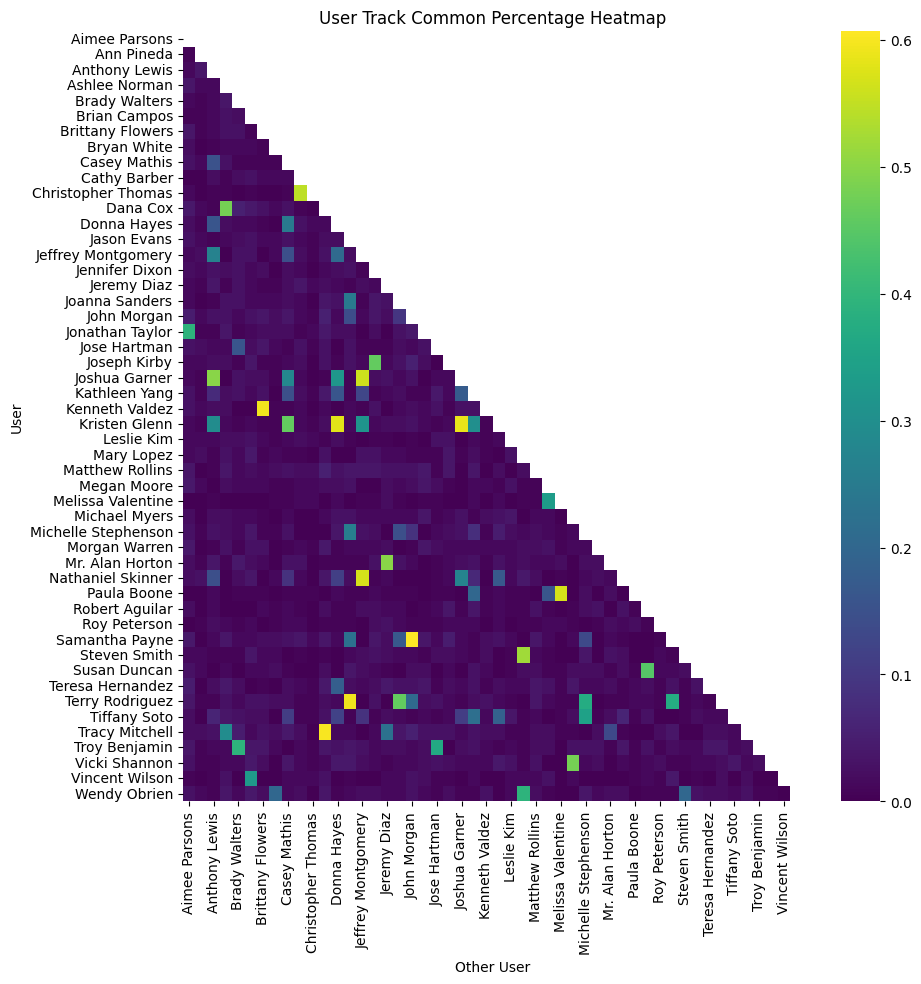

In [6]:
plot_user_similarities_matrix(df_track_common, figsize=(10, 10))

In [7]:
df.data.to_csv(os.path.join("data", "artificial_data.csv"))

In [ ]:
M = MatrixDataset(df.data, user_col="username", item_col="id", value_col="affinity")
M.R.shape

torch.Size([150, 14667])